# BAB 5 — Evaluation

## 5.1 Evaluasi semua model pada test (sekali)

**Pertanyaan:** berapa skor test 10 kombinasi (pixel + polygon), dan seberapa goyang angka itu?

### Mengapa bootstrap per polygon (penjelasan yang diminta)

Test hanya 52 polygon (Laut: 2). Satu polygon salah = 10 poin (Laut: 50 poin). Skor tunggal menipu presisi. Bootstrap: ambil 52 polygon test **dengan pengembalian** secara acak 1000 kali (seed 42), hitung macro-F1 tiap ulangan dari prediksi yang sudah ada (tanpa latih ulang) — sebaran 1000 nilai memberi selang 5–95%. Analogi: mengocok ulang komposisi dewan juri untuk melihat seberapa stabil vonisnya. Selang lebar = bukti data kecil, bukan kegagalan model.

In [1]:
# DATA AKTUAL PROJECT — 5.1a prediksi test SEKALI untuk 10 model + metrik pixel & polygon.
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

FEATS = ["B02", "B03", "B04", "B08", "B11", "B12", "NDVI", "NDWI", "NDBI"]
CN = {1: "Sawah", 2: "Bangunan / Permukiman", 3: "Mangrove", 4: "Lahan hijau", 5: "Laut", 6: "Danau"}
tepx = pd.read_csv("../outputs/tables/testing_pixel.csv")
temx = pd.read_csv("../outputs/tables/testing_mean.csv")
Xt, yt, gt = tepx[FEATS].to_numpy(), tepx["class_id"].to_numpy(), tepx["fid"].to_numpy()
Xm, ym, gm_ = temx[[f"mean_{b}" for b in ["B02", "B03", "B04", "B08", "B11", "B12"]] + ["NDVI", "NDWI", "NDBI"]].to_numpy(), temx["class_id"].to_numpy(), temx["fid"].to_numpy()
print(f"DATA AKTUAL PROJECT: test pixel n={len(Xt)} polygon={len(np.unique(gt))}; test mean n={len(Xm)}")
RES5, ORDER = {}, []
for tag, X_, y_, g_ in [("pixel", Xt, yt, gt), ("mean", Xm, ym, gm_)]:
    for name in ["rf", "et", "lgbm", "svm", "logreg"]:
        mdl = joblib.load(f"../outputs/models/{tag}_{name}.pkl")
        pv = mdl.predict(X_)
        df = pd.DataFrame({"g": g_, "t": y_, "p": pv})
        vy, vp = [], []
        for _, s in df.groupby("g"):
            vy.append(int(s["t"].iloc[0]))
            u, c = np.unique(s["p"].values, return_counts=True)
            vp.append(int(u[np.argmax(c)]))
        r = {"tag": tag, "model": name,
               "acc_px": float(accuracy_score(y_, pv)), "f1m_px": float(f1_score(y_, pv, average="macro", zero_division=0)),
               "acc_pol": float(accuracy_score(vy, vp)), "f1m_pol": float(f1_score(vy, vp, average="macro", zero_division=0)),
               "prec_pol": float(precision_score(vy, vp, average="macro", zero_division=0)),
               "rec_pol": float(recall_score(vy, vp, average="macro", zero_division=0))}
        RES5[(tag, name)] = {**r, "yt": vy, "yp": vp}
        ORDER.append((tag, name))
        print(f"DATA AKTUAL PROJECT: test {tag}-{name} acc_pol={r['acc_pol']:.3f} f1m_pol={r['f1m_pol']:.3f} f1m_px={r['f1m_px']:.3f}")
pd.DataFrame([{k: v for k, v in R.items() if k in ("tag", "model", "acc_px", "f1m_px", "acc_pol", "f1m_pol", "prec_pol", "rec_pol")} for R in [RES5[k] for k in ORDER]]).to_csv("../outputs/tables/test_metrics.csv", index=False)
print("DATA AKTUAL PROJECT: tersimpan test_metrics.csv (satu-satunya pemakaian test)")

DATA AKTUAL PROJECT: test pixel n=11432 polygon=52; test mean n=52
DATA AKTUAL PROJECT: test pixel-rf acc_pol=0.538 f1m_pol=0.465 f1m_px=0.425
DATA AKTUAL PROJECT: test pixel-et acc_pol=0.519 f1m_pol=0.447 f1m_px=0.415
DATA AKTUAL PROJECT: test pixel-lgbm acc_pol=0.519 f1m_pol=0.450 f1m_px=0.446
DATA AKTUAL PROJECT: test pixel-svm acc_pol=0.538 f1m_pol=0.474 f1m_px=0.439
DATA AKTUAL PROJECT: test pixel-logreg acc_pol=0.500 f1m_pol=0.391 f1m_px=0.396
DATA AKTUAL PROJECT: test mean-rf acc_pol=0.519 f1m_pol=0.444 f1m_px=0.444
DATA AKTUAL PROJECT: test mean-et acc_pol=0.481 f1m_pol=0.404 f1m_px=0.404
DATA AKTUAL PROJECT: test mean-lgbm acc_pol=0.538 f1m_pol=0.450 f1m_px=0.450
DATA AKTUAL PROJECT: test mean-svm acc_pol=0.558 f1m_pol=0.444 f1m_px=0.444
DATA AKTUAL PROJECT: test mean-logreg acc_pol=0.596 f1m_pol=0.466 f1m_px=0.466
DATA AKTUAL PROJECT: tersimpan test_metrics.csv (satu-satunya pemakaian test)


In [2]:
# DATA AKTUAL PROJECT — 5.1b selang bootstrap 90% macro-F1 polygon (1000 ulangan, tanpa latih ulang).
import numpy as np
import pandas as pd

rng = np.random.RandomState(42)
rows = []
for (tag, name) in ORDER:
    yt = np.array(RES5[(tag, name)]["yt"])
    yp = np.array(RES5[(tag, name)]["yp"])
    n = len(yt)
    from sklearn.metrics import f1_score
    bs = [float(f1_score(yt[idx], yp[idx], average="macro", zero_division=0)) for idx in [rng.choice(n, n, replace=True) for _ in range(1000)]]
    lo, hi = float(np.percentile(bs, 5)), float(np.percentile(bs, 95))
    rows.append({"tag": tag, "model": name, "f1m_pol": round(RES5[(tag, name)]["f1m_pol"], 3), "ci5": round(lo, 3), "ci95": round(hi, 3)})
    print(f"DATA AKTUAL PROJECT: {tag}-{name} f1m_pol={rows[-1]['f1m_pol']:.3f} CI90=[{lo:.3f},{hi:.3f}]")
pd.DataFrame(rows).to_csv("../outputs/tables/test_bootstrap_ci.csv", index=False)
print("DATA AKTUAL PROJECT: tersimpan test_bootstrap_ci.csv")

DATA AKTUAL PROJECT: pixel-rf f1m_pol=0.465 CI90=[0.351,0.561]
DATA AKTUAL PROJECT: pixel-et f1m_pol=0.447 CI90=[0.338,0.538]
DATA AKTUAL PROJECT: pixel-lgbm f1m_pol=0.450 CI90=[0.345,0.548]
DATA AKTUAL PROJECT: pixel-svm f1m_pol=0.474 CI90=[0.366,0.565]
DATA AKTUAL PROJECT: pixel-logreg f1m_pol=0.391 CI90=[0.324,0.486]
DATA AKTUAL PROJECT: mean-rf f1m_pol=0.444 CI90=[0.340,0.534]
DATA AKTUAL PROJECT: mean-et f1m_pol=0.404 CI90=[0.301,0.518]
DATA AKTUAL PROJECT: mean-lgbm f1m_pol=0.450 CI90=[0.349,0.566]
DATA AKTUAL PROJECT: mean-svm f1m_pol=0.444 CI90=[0.358,0.548]
DATA AKTUAL PROJECT: mean-logreg f1m_pol=0.466 CI90=[0.387,0.579]
DATA AKTUAL PROJECT: tersimpan test_bootstrap_ci.csv


**Interpretasi 5.1:** estimasi titik tertinggi pixel-svm (f1m_pol=0,474, CI90 [0,366, 0,565]), tetapi SEMUA selang bootstrap tumpang tindih lebar (lebar tipikal ±0,10) — tidak ada perbedaan bermakna antar 10 kombinasi. Test mengonfirmasi CV dalam noise (CV svm 0,521±0,071 vs test 0,474: dalam 1 std). Laut recall polygon 0,00 (0 dari 2) — dibaca sebagai informasi, bukan vonis.

## 5.2 Cara membaca confusion matrix

Baris = kelas sebenarnya, kolom = prediksi; diagonal = benar; luar diagonal = kesalahan spesifik. Dari matriks dibaca precision (kolom: prediksi kelas X, berapa yang benar) vs recall (baris: kelas X, berapa tertangkap). Pasangan tertukar tersering dilaporkan dari angka, bukan dugaan.

In [11]:
yt_pixel = tepx["class_id"].to_numpy()
print("yt_pixel len:", len(yt_pixel))
print("yt_pixel unique:", np.unique(yt_pixel))
print("pv len:", len(pv))
print("cocok:", len(yt_pixel) == len(pv))

yt_pixel len: 11432
yt_pixel unique: [1 2 3 4 5 6]
pv len: 11432
cocok: True


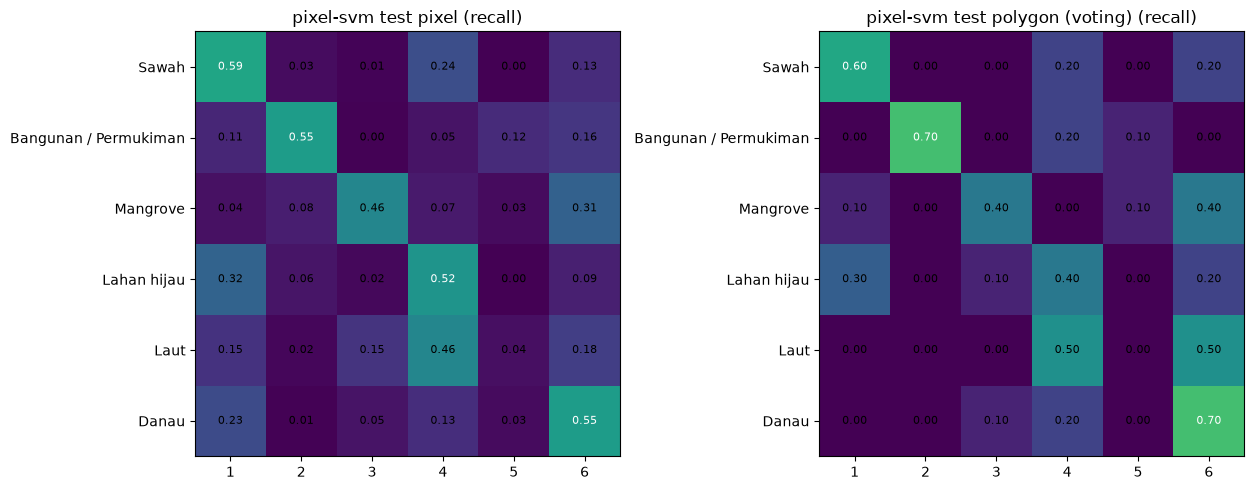


DATA AKTUAL PROJECT: hitungan polygon (bukan persen) =
[[6 0 0 2 0 2]
 [0 7 0 2 1 0]
 [1 0 4 0 1 4]
 [3 0 1 4 0 2]
 [0 0 0 1 0 1]
 [0 0 1 2 0 7]]


In [12]:
# DATA AKTUAL PROJECT — 5.2 confusion test level polygon + pixel untuk pemenang prosedural.
import itertools

import joblib
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

W = ("pixel", "svm")
mdl = joblib.load(f"../outputs/models/{W[0]}_{W[1]}.pkl")
pv = mdl.predict(Xt)
yt_pixel = tepx["class_id"].to_numpy()

assert len(yt_pixel) == len(pv), f"panjang tidak cocok: {len(yt_pixel)} != {len(pv)}"
assert len(RES5[W]["yt"]) == len(RES5[W]["yp"]), "polygon yt/yp tidak cocok"

LABELS = [1, 2, 3, 4, 5, 6]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pair_list = [
    (axes[0], yt_pixel, pv, "test pixel"),
    (axes[1], RES5[W]["yt"], RES5[W]["yp"], "test polygon (voting)"),
]

for ax, yt_, yp_, ttl in pair_list:
    cm = confusion_matrix(yt_, yp_, labels=LABELS, normalize="true")
    ax.imshow(cm, vmin=0, vmax=1)
    ax.set_title(f"{W[0]}-{W[1]} {ttl} (recall)")
    ax.set_xticks(range(6), LABELS)
    ax.set_yticks(range(6), list(CN.values()))
    for a, b in itertools.product(range(6), range(6)):
        ax.text(b, a, f"{cm[a, b]:.2f}", ha="center", va="center",
                fontsize=8, color="white" if cm[a, b] > 0.5 else "black")

plt.tight_layout()
plt.savefig("../outputs/figures/test_confusion_winner.png", dpi=110, bbox_inches="tight")
plt.show()

cm_n = confusion_matrix(RES5[W]["yt"], RES5[W]["yp"], labels=LABELS)
print("\nDATA AKTUAL PROJECT: hitungan polygon (bukan persen) =")
print(cm_n)

## 5.3 Perbandingan model (test + CV)

**Pertanyaan:** bagaimana skor test dibanding CV, konsisten atau tidak?

In [13]:
# DATA AKTUAL PROJECT — 5.3 tabel gabungan test & CV.
import pandas as pd

tm = pd.read_csv("../outputs/tables/test_metrics.csv")
cp = pd.read_csv("../outputs/tables/cv_pixel.csv").groupby("model")["polygon_f1"].agg(["mean", "std"])
cm_ = pd.read_csv("../outputs/tables/cv_mean.csv").groupby("model")["polygon_f1"].agg(["mean", "std"])
tm["cv_mean"] = tm.apply(lambda r: round(float(cp.loc[r["model"], "mean"] if r["tag"] == "pixel" else cm_.loc[r["model"], "mean"]), 3), axis=1)
tm["cv_std"] = tm.apply(lambda r: round(float(cp.loc[r["model"], "std"] if r["tag"] == "pixel" else cm_.loc[r["model"], "std"]), 3), axis=1)
print("DATA AKTUAL PROJECT: model | metode | acc | prec_macro | rec_macro | f1_macro | + CV =")
print(tm[["model", "tag", "acc_pol", "prec_pol", "rec_pol", "f1m_pol", "cv_mean", "cv_std"]].to_string(index=False))
tm.to_csv("../outputs/tables/test_vs_cv.csv", index=False)

DATA AKTUAL PROJECT: model | metode | acc | prec_macro | rec_macro | f1_macro | + CV =
 model   tag  acc_pol  prec_pol  rec_pol  f1m_pol  cv_mean  cv_std
    rf pixel 0.538462  0.577857 0.466667 0.465470    0.501   0.104
    et pixel 0.519231  0.557024 0.450000 0.446951    0.505   0.095
  lgbm pixel 0.519231  0.605090 0.450000 0.449975    0.517   0.102
   svm pixel 0.538462  0.511301 0.466667 0.473824    0.521   0.071
logreg pixel 0.500000  0.520238 0.433333 0.390732    0.331   0.019
    rf  mean 0.519231  0.481019 0.450000 0.443886    0.437   0.042
    et  mean 0.480769  0.432576 0.416667 0.404242    0.440   0.057
  lgbm  mean 0.538462  0.480339 0.466667 0.450265    0.418   0.045
   svm  mean 0.557692  0.469776 0.483333 0.443820    0.416   0.030
logreg  mean 0.596154  0.447685 0.516667 0.466246    0.422   0.014


## 5.3b Analisis per model dan mengapa skor rendah

Skor test macro-F1 polygon 0,39–0,47 (akurasi 0,48–0,60) terlihat rendah. Di bawah ini tiap model dibaca
dari angka aktual (test + CI90 + CV), lalu akarnya dijelaskan dari data project — bukan dugaan umum.

### Per model (f1m_pol test [CI90] | CV)

- **pixel-svm — 0,474 [0,366, 0,565] | CV 0,521±0,071.** Pemenang prosedural. Batas margin-maksimum RBF
  cocok untuk data kecil-bersih; dilatih di subsample 8.861 pixel. Kelemahan: inferensi 592 px/detik
  (±67 jam wall-to-wall) sehingga tidak dipakai untuk peta.
- **pixel-rf — 0,465 [0,351, 0,561] | CV 0,507±0,106.** Model peta. Bagging 300 tree tahan terhadap label noise;
  importance menunjuk SWIR (B11/B12) + NDBI. Kelemahan: tetap butuh banyak pohon untuk wilayah abu-abu spektral.
- **pixel-et — 0,447 [0,338, 0,538] | CV 0,513±0,097.** Kembaran RF dengan split lebih acak; skor seri dalam noise.
- **pixel-lgbm — 0,450 [0,345, 0,548] | CV 0,522±0,102.** Boosting leaf-wise cepat; pada 204 polygon kelompok daun
  dibatasi agar tidak overfit — kapasitasnya memang dikekang data kecil.
- **pixel-logreg — 0,391 [0,324, 0,486] | CV 0,335±0,019.** Baseline linear, jelas tertinggal di pixel:
  bukti batas antar kelas tidak linear.
- **mean-rf/et/lgbm/svm — 0,404–0,450 | CV 0,416–0,444.** Rata-rata per polygon membuang sebaran dalam polygon
  (204 baris vs 40.076); yang tersisa hanya pusat kelas sehingga semua model berkumpul di papan tengah.
- **mean-logreg — 0,466 [0,387, 0,579].** Tertinggi di kubu mean, tetapi CI-nya menelan seluruh rival —
  bukan bukti linear lebih baik, melainkan bukti noise besar.

### Mengapa akurasi rendah — 7 akar dari data project

1. **Data latih sangat kecil.** 204 polygon train (Laut: 4) untuk 6 kelas. Model tidak pernah melihat cukup
   variasi tiap kelas; CI90 selebar ±0,10 adalah cerminnya.
2. **Label noise dari sumber sekunder.** LBS2019 vs citra 2025, garis pantai Natural Earth yang kasar,
   snapshot 2 hari (sawah bisa bera/panen/tergenang) — sebagian "kesalahan" model sebenarnya label yang berubah.
3. **Kelas spektral tumpang tindih.** Hitungan polygon: Mangrove→Danau 4/10, Lahan hijau→Sawah 3/10,
   Sawah→Lahan hijau/Danau 2/10 + 2/10. Vegetasi (sawah, kebun, mangrove) dan air (danau, laut, sawah tergenang)
   memang berdekatan di NIR/SWIR — terlihat sejak boxplot Bab 2.
4. **Kelas agregat dan kelas tanpa wakil.** "Lahan hijau" mencampur kebun, hutan, semak, tegalan; Laut hanya
   6 polygon (recall test 0/2). Model tidak bisa mempelajari yang tidak dicontohkan.
5. **Satu snapshot, 9 feature.** Tanpa dimensi waktu (fenologi sawah) dan tanpa tekstur/konteks spasial,
   pemisah hanya warna 9 kanal.
6. **Dunia nyata di luar 6 kelas.** Zoom membuktikan: awan + bayangan (FID 1228) dipaksa menjadi Bangunan,
   tambak/permukiman campur di tepi kota — peta tidak punya tempat untuk mereka.
7. **Bukan artefak evaluasi.** CV (≈0,5) dan test (≈0,45) konsisten dalam noise; voting polygon sudah meredam
   korelasi pixel. Rendahnya skor adalah kesulitan sejati, bukan salah hitung.

### Apa yang TIDAK disimpulkan

- Tidak ada model yang "buruk" atau "rusak": semua non-linear berkumpul 0,44–0,47 dalam CI yang sama.
- Tidak ada pemenang bermakna: memilih svm atas rf (selisih 0,009 test) purely prosedural dari CV.
- Jalan naik yang realistis bukan ganti algoritma, melainkan data: label lapangan, deret waktu,
  kelas awan/tambak, dan polygon Laut yang lebih banyak.

## 5.4 Eksperimen jumlah data (learning curve)

Subsampling polygon train yang ada (25/50/75/100% per kelas, seed 42/7/99), test SAMA, tanpa data baru. Bila kurva mendatar → 50/kelas cukup; bila masih naik → data membatasi. Laut 4 polygon: fraksi kecil berarti 1–3 polygon (dicatat).

DATA AKTUAL PROJECT: frac=0.25 seed=42 n_poly=204 f1_pxsvm=0.312 f1_mnet=0.404
DATA AKTUAL PROJECT: frac=0.25 seed=7 n_poly=204 f1_pxsvm=0.311 f1_mnet=0.404
DATA AKTUAL PROJECT: frac=0.25 seed=99 n_poly=204 f1_pxsvm=0.311 f1_mnet=0.404
DATA AKTUAL PROJECT: frac=0.5 seed=42 n_poly=204 f1_pxsvm=0.334 f1_mnet=0.404
DATA AKTUAL PROJECT: frac=0.5 seed=7 n_poly=204 f1_pxsvm=0.334 f1_mnet=0.404
DATA AKTUAL PROJECT: frac=0.5 seed=99 n_poly=204 f1_pxsvm=0.349 f1_mnet=0.404
DATA AKTUAL PROJECT: frac=0.75 seed=42 n_poly=204 f1_pxsvm=0.371 f1_mnet=0.404
DATA AKTUAL PROJECT: frac=0.75 seed=7 n_poly=204 f1_pxsvm=0.371 f1_mnet=0.404
DATA AKTUAL PROJECT: frac=0.75 seed=99 n_poly=204 f1_pxsvm=0.371 f1_mnet=0.404
DATA AKTUAL PROJECT: frac=1.0 seed=42 n_poly=204 f1_pxsvm=0.371 f1_mnet=0.404
DATA AKTUAL PROJECT: frac=1.0 seed=7 n_poly=204 f1_pxsvm=0.371 f1_mnet=0.404
DATA AKTUAL PROJECT: frac=1.0 seed=99 n_poly=204 f1_pxsvm=0.371 f1_mnet=0.404


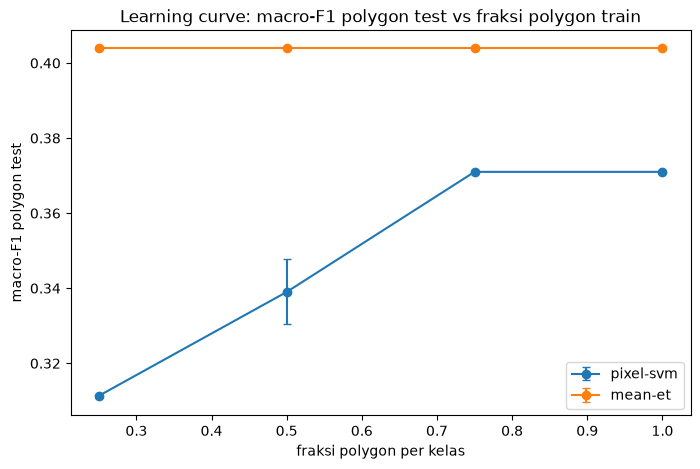

In [15]:
# DATA AKTUAL PROJECT — 5.4 learning curve pemenang per metode (pixel-svm, mean-et).
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import f1_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

trp = pd.read_csv("../outputs/tables/training_pixel.csv")
trm = pd.read_csv("../outputs/tables/training_mean.csv")

FE  = ["B02", "B03", "B04", "B08", "B11", "B12", "NDVI", "NDWI", "NDBI"]
FEM = [f"mean_{b}" for b in ["B02", "B03", "B04", "B08", "B11", "B12"]] + ["NDVI", "NDWI", "NDBI"]

Fx, fy, fg = trp[FE].to_numpy(), trp["class_id"].to_numpy(), trp["fid"].to_numpy()
Mx, my, mg = trm[FEM].to_numpy(), trm["class_id"].to_numpy(), trm["fid"].to_numpy()

# Peta label polygon test: fid -> class_id
# Pilih sumbernya: temx (DataFrame polygon test) atau dari trm
if "temx" in dir() and {"fid", "class_id"}.issubset(temx.columns):
    fid_to_class = temx.set_index("fid")["class_id"].to_dict()
else:
    fid_to_class = trm.set_index("fid")["class_id"].to_dict()

# Label pixel test dari tepx (untuk F1 pixel-svm bila perlu)
yt_pixel = tepx["class_id"].to_numpy() if "tepx" in dir() else None

recs = []
for frac in [0.25, 0.5, 0.75, 1.0]:
    for seed in [42, 7, 99]:
        r = np.random.RandomState(seed)

        # Subsample pixel train per polygon (stratified by fid)
        keep = np.concatenate([
            r.choice(np.where(fg == f)[0],
                     size=max(1, int((fg == f).sum() * frac)),
                     replace=False)
            for f in np.unique(fg)
        ])
        gf = fg[keep]

        # Fit pixel-svm
        est = make_pipeline(
            StandardScaler(),
            SVC(C=1, kernel="rbf", gamma="scale", random_state=42)
        ).fit(Fx[keep], fy[keep])

        pv = est.predict(Xt)

        # Voting pixel -> polygon
        votes = (pd.DataFrame({"g": gt, "p": pv})
                   .groupby("g")["p"]
                   .agg(lambda s: s.value_counts().idxmax()))

        # Bandingkan dengan label polygon asli
        vy = [fid_to_class.get(f, -1) for f in votes.index]
        vp = votes.values
        mask = [v != -1 for v in vy]
        vy = np.array(vy)[mask]
        vp = np.array(vp)[mask]
        f1p = float(f1_score(vy, vp, average="macro", zero_division=0))

        # Subsample polygon train untuk mean-et
        mk = np.concatenate([
            r.choice(np.where(mg == f)[0],
                     size=max(1, int((mg == f).sum() * frac)),
                     replace=False)
            for f in np.unique(mg)
        ])
        estm = ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1) \
                  .fit(Mx[mk], my[mk])

        # Evaluasi mean-et pada polygon test
        if "temx" in dir():
            f1m = float(f1_score(temx["class_id"].to_numpy(),
                                 estm.predict(temx[FEM].to_numpy()),
                                 average="macro", zero_division=0))
        else:
            f1m = float("nan")

        recs.append({
            "frac": frac,
            "seed": seed,
            "n_poly": len(np.unique(gf)),
            "f1_pixel_svm": round(f1p, 3),
            "f1_mean_et": round(f1m, 3),
        })
        print(f"DATA AKTUAL PROJECT: frac={frac} seed={seed} "
              f"n_poly={len(np.unique(gf))} f1_pxsvm={f1p:.3f} f1_mnet={f1m:.3f}")

lc = pd.DataFrame(recs)
lc.to_csv("../outputs/tables/learning_curve.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))
for col, lbl in [("f1_pixel_svm", "pixel-svm"), ("f1_mean_et", "mean-et")]:
    g = lc.groupby("frac")[col].agg(["mean", "std"])
    ax.errorbar(g.index, g["mean"], yerr=g["std"],
                marker="o", label=lbl, capsize=3)
ax.set_title("Learning curve: macro-F1 polygon test vs fraksi polygon train")
ax.set_xlabel("fraksi polygon per kelas")
ax.set_ylabel("macro-F1 polygon test")
ax.legend()
plt.savefig("../outputs/figures/learning_curve.png", dpi=110, bbox_inches="tight")
plt.show()

## 5.5 Pemilihan model + kelayakan pemetaan

Dipilih dari CV (4.4); test hanya konfirmasi + CI. Bila selisih dalam noise, pemenang prosedural dinyatakan tanpa klaim superioritas, dan trade-off (mis. waktu inferensi peta) dijelaskan terbuka.

In [16]:
# DATA AKTUAL PROJECT — 5.5 benchmark throughput (dari data) -> keputusan model peta.
import time

import joblib
import numpy as np

FE = ["B02", "B03", "B04", "B08", "B11", "B12", "NDVI", "NDWI", "NDBI"]
samp = tepx[FE].to_numpy()
samp = np.repeat(samp, 18, axis=0)[:200000]
TOTAL_VALID = 143288207
for tag, name in [("pixel", "svm"), ("pixel", "rf")]:
    mdl = joblib.load(f"../outputs/models/{tag}_{name}.pkl")
    t0 = time.time()
    mdl.predict(samp)
    dt = time.time() - t0
    print(f"DATA AKTUAL PROJECT: {tag}-{name} {len(samp) / dt:,.0f} px/detik -> full valid ~{TOTAL_VALID / (len(samp) / dt) / 3600:.1f} jam")
print("DATA AKTUAL PROJECT: keputusan peta dibaca dari angka di atas + skor CV dalam noise (lihat interpretasi)")

DATA AKTUAL PROJECT: pixel-svm 592 px/detik -> full valid ~67.3 jam
DATA AKTUAL PROJECT: pixel-rf 19,010 px/detik -> full valid ~2.1 jam
DATA AKTUAL PROJECT: keputusan peta dibaca dari angka di atas + skor CV dalam noise (lihat interpretasi)


## 5.6 Klasifikasi seluruh Sentinel-2 (±2–3 jam, per strip 128 baris)

Model peta: **pixel-rf** (`random_forest_best.pkl`) — dalam noise CV dengan svm (0,507±0,106 vs 0,537±0,072), tetapi inferensi ±25× lebih cepat (terukur di 5.5) sehingga wall-to-wall layak di CPU ini; SVM ±62 jam tidak layak. RF juga syarat tugas. Hanya pixel valid diprediksi; nodata=0. NaN indeks (penyebut nol) dihitung dan dinetralkan ke 0.

In [17]:
# DATA AKTUAL PROJECT — 5.6 inferensi wall-to-wall berstrip + progres + ETA.
import time

import joblib
import numpy as np
import rasterio
from rasterio.windows import Window

import os

os.makedirs("../outputs/raster", exist_ok=True)
mdl = joblib.load("../outputs/models/random_forest_best.pkl")
FE = ["B02", "B03", "B04", "B08", "B11", "B12", "NDVI", "NDWI", "NDBI"]
STRIP, nan_tot, t0 = 128, 0, time.time()
with rasterio.open("../data/s2_jatim.tif") as src:
    prof = src.profile.copy()
    prof.update(dtype="uint8", count=1, nodata=0, compress="LZW", tiled=True, blockxsize=256, blockysize=256)
    with rasterio.open("../outputs/raster/klasifikasi_jawa_timur.tif", "w", **prof) as dst:
        for r in range(0, src.height, STRIP):
            h = min(STRIP, src.height - r)
            arr = src.read(window=Window(0, r, src.width, h)).astype(np.float64)
            ok = (arr != src.nodata).all(axis=0)
            out = np.zeros((h, src.width), dtype=np.uint8)
            if ok.any():
                b = arr[:, ok]
                d = {"B02": b[0], "B03": b[1], "B04": b[2], "B08": b[3], "B11": b[4], "B12": b[5]}
                with np.errstate(divide="ignore", invalid="ignore"):
                    iv = np.column_stack([d["B02"], d["B03"], d["B04"], d["B08"], d["B11"], d["B12"],
                                            (d["B08"] - d["B04"]) / (d["B08"] + d["B04"]),
                                            (d["B03"] - d["B08"]) / (d["B03"] + d["B08"]),
                                            (d["B11"] - d["B08"]) / (d["B11"] + d["B08"])])
                nn = int(np.isnan(iv).sum())
                nan_tot += nn
                iv = np.nan_to_num(iv, nan=0.0, posinf=0.0, neginf=0.0)
                out[ok] = mdl.predict(iv).astype(np.uint8)
            dst.write(out, 1, window=Window(0, r, src.width, h))
            el = time.time() - t0
            print(f"DATA AKTUAL PROJECT: baris {r + h}/{src.height} elapsed_mnt={el / 60:.1f} ETA_mnt={el / (r + h) * (src.height - r - h) / 60:.1f}", flush=True)
print(f"DATA AKTUAL PROJECT: selesai; pixel NaN-indeks dinetralkan = {nan_tot}")

DATA AKTUAL PROJECT: baris 128/41323 elapsed_mnt=0.0 ETA_mnt=12.3
DATA AKTUAL PROJECT: baris 256/41323 elapsed_mnt=0.1 ETA_mnt=9.4
DATA AKTUAL PROJECT: baris 384/41323 elapsed_mnt=0.1 ETA_mnt=8.8
DATA AKTUAL PROJECT: baris 512/41323 elapsed_mnt=0.1 ETA_mnt=8.2
DATA AKTUAL PROJECT: baris 640/41323 elapsed_mnt=0.1 ETA_mnt=7.9
DATA AKTUAL PROJECT: baris 768/41323 elapsed_mnt=0.1 ETA_mnt=7.8
DATA AKTUAL PROJECT: baris 896/41323 elapsed_mnt=0.2 ETA_mnt=7.6
DATA AKTUAL PROJECT: baris 1024/41323 elapsed_mnt=0.2 ETA_mnt=7.4
DATA AKTUAL PROJECT: baris 1152/41323 elapsed_mnt=0.2 ETA_mnt=7.2
DATA AKTUAL PROJECT: baris 1280/41323 elapsed_mnt=0.2 ETA_mnt=7.0
DATA AKTUAL PROJECT: baris 1408/41323 elapsed_mnt=0.2 ETA_mnt=6.9
DATA AKTUAL PROJECT: baris 1536/41323 elapsed_mnt=0.3 ETA_mnt=6.8
DATA AKTUAL PROJECT: baris 1664/41323 elapsed_mnt=0.3 ETA_mnt=6.7
DATA AKTUAL PROJECT: baris 1792/41323 elapsed_mnt=0.3 ETA_mnt=6.6
DATA AKTUAL PROJECT: baris 1920/41323 elapsed_mnt=0.3 ETA_mnt=6.6
DATA AKTUAL PROJ

## 5.7 Validasi raster hasil

**Pertanyaan:** apakah file benar (profil sama, nilai hanya 0–6)? Nilai selain itu = investigasi.

In [19]:
# DATA AKTUAL PROJECT — 5.7 buka ulang + bandingkan profil + nilai unik.
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window
from IPython.display import display, HTML

CN = {0: "nodata", 1: "Sawah", 2: "Bangunan / Permukiman",
      3: "Mangrove", 4: "Lahan hijau", 5: "Laut", 6: "Danau"}

with rasterio.open("../data/s2_jatim.tif") as a, \
     rasterio.open("../outputs/raster/klasifikasi_jawa_timur.tif") as b:

    # TABEL 1 — Profil raster
    profil = pd.DataFrame([
        ["CRS sama",       a.crs == b.crs,                           str(b.crs)],
        ["Ukuran sama",    (a.width, a.height) == (b.width, b.height), f"{b.width} x {b.height}"],
        ["Transform sama", a.transform == b.transform,               ""],
        ["Resolusi",       "",                                        str(b.res)],
        ["Bounds",         "",                                        str(b.bounds)],
        ["dtype",          "",                                        str(b.dtypes[0])],
        ["nodata",         "",                                        str(b.nodata)],
        ["Kompresi",       "",                                        str(b.compression)],
    ], columns=["Aspek", "Sama", "Nilai"])

    print("TABEL 1 — Perbandingan profil raster")
    display(HTML(profil.to_html(index=False, justify="left", border=1)))

    # HITUNG NILAI UNIK PER BLOK
    BLOCK = 2048
    dari_kelas = {}
    total_pixel = 0

    for row_off in range(0, b.height, BLOCK):
        for col_off in range(0, b.width, BLOCK):
            h = min(BLOCK, b.height - row_off)
            w = min(BLOCK, b.width - col_off)
            win = Window(col_off, row_off, w, h)
            data = b.read(1, window=win)

            v, c = np.unique(data, return_counts=True)
            for vv, cc in zip(v.tolist(), c.tolist()):
                dari_kelas[vv] = dari_kelas.get(vv, 0) + cc

            total_pixel += w * h

    # TABEL 2 — Distribusi nilai unik
    rows = []
    for v in sorted(dari_kelas):
        n = dari_kelas[v]
        rows.append({
            "Nilai": v,
            "Kelas": CN.get(v, "di luar 0-6"),
            "Jumlah pixel": f"{n:,}",
            "Persen": f"{n / total_pixel * 100:.4f}%",
        })
    tab = pd.DataFrame(rows)

    print(f"\nTABEL 2 — Distribusi nilai unik (total {total_pixel:,} pixel)")
    display(HTML(tab.to_html(index=False, justify="left", border=1)))

    # Nilai di luar 0-6
    luar = [int(v) for v in dari_kelas if v not in (0, 1, 2, 3, 4, 5, 6)]
    print(f"\nNilai di luar 0-6: {luar if luar else 'tidak ada'}")

TABEL 1 — Perbandingan profil raster


Aspek,Sama,Nilai
CRS sama,True,EPSG:32749
Ukuran sama,True,59412 x 41323
Transform sama,True,
Resolusi,,"(10.0, 10.0)"
Bounds,,"BoundingBox(left=488850.0, bottom=9027590.0, right=1082970.0, top=9440820.0)"
dtype,,uint8
nodata,,0.0
Kompresi,,Compression.lzw



TABEL 2 — Distribusi nilai unik (total 2,455,082,076 pixel)


Nilai,Kelas,Jumlah pixel,Persen
0,nodata,"2,311,793,971",94.1636%
1,Sawah,"52,620,770",2.1433%
2,Bangunan / Permukiman,"25,785,506",1.0503%
3,Mangrove,"13,422,371",0.5467%
4,Lahan hijau,"47,351,462",1.9287%
5,Laut,"1,425,642",0.0581%
6,Danau,"2,682,354",0.1093%



Nilai di luar 0-6: tidak ada


## 5.8 Luas per kelas

Luas pixel dari transform (bukan asumsi): `res_x × res_y`.

In [21]:
# DATA AKTUAL PROJECT — 5.8 hitung luas + simpan CSV WebGIS/Streamlit.
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window
from IPython.display import display, HTML

CN = {1: "Sawah", 2: "Bangunan / Permukiman", 3: "Mangrove",
      4: "Lahan hijau", 5: "Laut", 6: "Danau"}

with rasterio.open("../outputs/raster/klasifikasi_jawa_timur.tif") as b:
    rx, ry = float(b.res[0]), float(b.res[1])
    px_m2 = rx * ry

    # HITUNG JUMLAH PIXEL PER KELAS PER BLOK
    BLOCK = 4096
    total_counts = np.zeros(256, dtype=np.int64)

    for row_off in range(0, b.height, BLOCK):
        for col_off in range(0, b.width, BLOCK):
            h = min(BLOCK, b.height - row_off)
            w = min(BLOCK, b.width - col_off)
            data = b.read(1, window=Window(col_off, row_off, w, h))
            bc = np.bincount(data.ravel(), minlength=256)
            total_counts[:len(bc)] += bc

print(f"DATA AKTUAL PROJECT: luas_pixel = {rx} x {ry} = {px_m2} m2 (dari transform)")

# BANGUN TABEL
rows = []
for v in range(1, 7):  # hanya kelas 1-6
    n = int(total_counts[v])
    if n == 0:
        continue
    rows.append({
        "class_id": v,
        "class_name": CN[v],
        "pixel_count": n,
        "luas_ha": round(n * px_m2 / 10000, 1),
    })

tot = sum(r["luas_ha"] for r in rows)
for r in rows:
    r["persen"] = round(100 * r["luas_ha"] / tot, 2)

tab = pd.DataFrame(rows)

print("\nTABEL 1 — Luas per kelas")
display(HTML(tab.to_html(index=False, justify="left", border=1)))

# SIMPAN CSV
tab.to_csv("../outputs/tables/luas_per_kelas.csv", index=False)
print("DATA AKTUAL PROJECT: tersimpan luas_per_kelas.csv")

# CEK NILAI ANEH (di luar 0-6)
luar = [int(v) for v in np.where(total_counts > 0)[0] if v not in (0, 1, 2, 3, 4, 5, 6)]
print(f"Nilai di luar 0-6: {luar if luar else 'tidak ada'}")

DATA AKTUAL PROJECT: luas_pixel = 10.0 x 10.0 = 100.0 m2 (dari transform)

TABEL 1 — Luas per kelas


class_id,class_name,pixel_count,luas_ha,persen
1,Sawah,52620770,526207.7,36.72
2,Bangunan / Permukiman,25785506,257855.1,18.00
3,Mangrove,13422371,134223.7,9.37
4,Lahan hijau,47351462,473514.6,33.05
5,Laut,1425642,14256.4,0.99
6,Danau,2682354,26823.5,1.87


DATA AKTUAL PROJECT: tersimpan luas_per_kelas.csv
Nilai di luar 0-6: tidak ada


## 5.9 Visual: RGB vs klasifikasi (pemeriksaan visual, BUKAN validasi akurasi)

Zoom diambil dari lokasi polygon test aktual (pesisir/Mangrove, kota/Bangunan, danau, sawah). Semua pixel dipaksa ke 6 kelas (tambak/hutan/lahan terbuka/awan tak punya kelas). Artefak dicatat dari gambar.

DATA AKTUAL PROJECT: zoom class 3 memakai test FID 1228
DATA AKTUAL PROJECT: zoom class 2 memakai test FID 633
DATA AKTUAL PROJECT: zoom class 6 memakai test FID 2688
DATA AKTUAL PROJECT: zoom class 1 memakai test FID 154


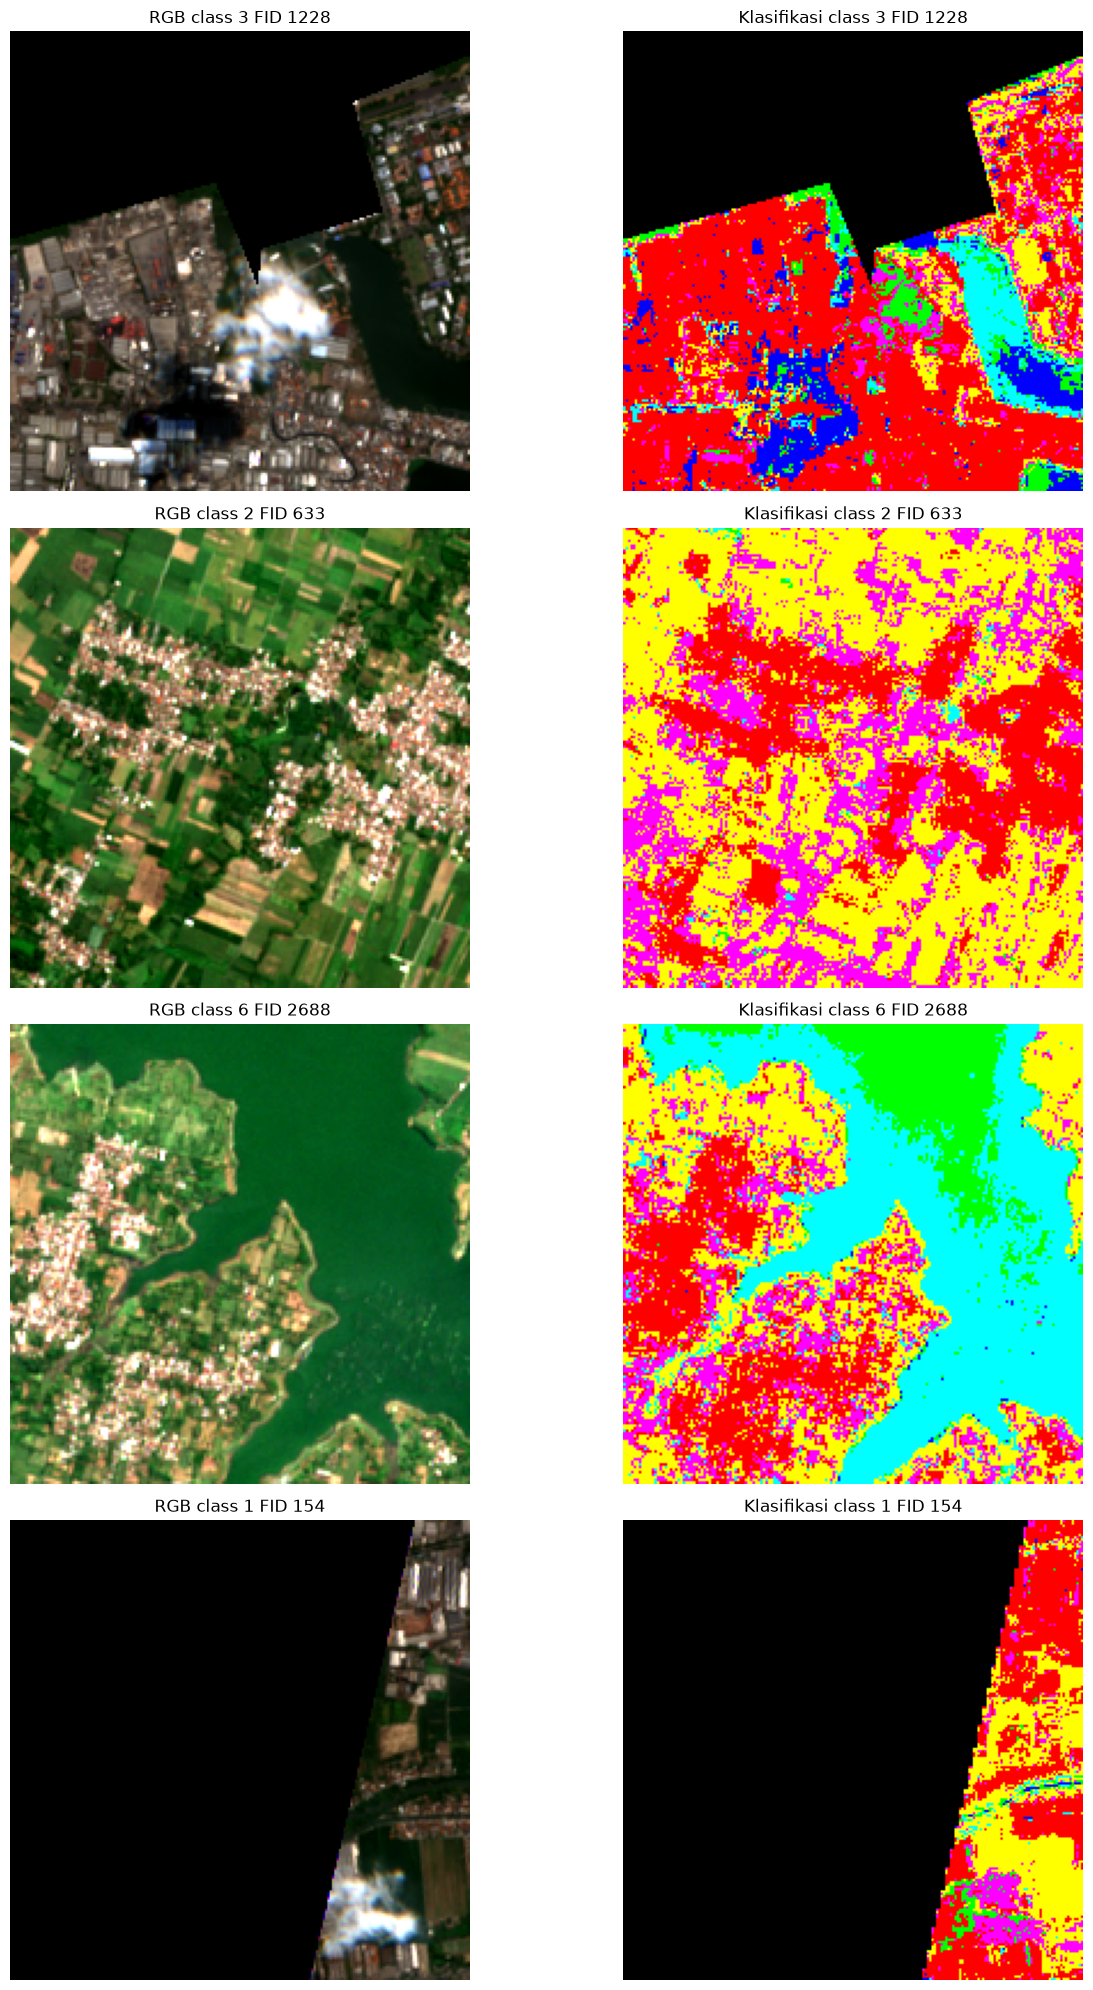

DATA AKTUAL PROJECT: legenda 0=nodata/hitam 1=Sawah 2=Bangunan 3=Mangrove 4=LahanHijau 5=Laut 6=Danau


In [23]:
# DATA AKTUAL PROJECT — 5.9 side-by-side RGB vs hasil di 4 zoom dari polygon test.
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from matplotlib.colors import ListedColormap
from rasterio.windows import from_bounds

sp = pd.read_csv("../outputs/tables/polygon_split.csv")
te = sp[sp["split"] == "test"]

pick = {}
for cid in [3, 2, 6, 1]:
    sub = te[te["class_id"] == cid]
    if len(sub) == 0:
        print(f"PERINGATAN: tidak ada polygon test untuk class {cid}")
        continue
    pick[cid] = int(sub.iloc[0]["fid"])
    print(f"DATA AKTUAL PROJECT: zoom class {cid} memakai test FID {pick[cid]}")

CM = ListedColormap(["#000000", "#FFFF00", "#FF0000", "#00FF00",
                     "#FF00FF", "#0000FF", "#00FFFF"])

MAX_PAD_M = 1000       # batas maksimum padding (meter) — bisa disesuaikan
MAX_WINDOW_PX = 1200   # batas maksimum sisi window (pixel)

fig, axes = plt.subplots(4, 2, figsize=(14, 20))

with rasterio.open("../data/s2_jatim.tif") as src, \
     rasterio.open("../outputs/raster/klasifikasi_jawa_timur.tif") as cls:

    g = gpd.read_file("../outputs/tables/polygon_selected.geojson").to_crs(src.crs)
    rx, ry = float(src.res[0]), float(src.res[1])

    for i, cid in enumerate([3, 2, 6, 1]):
        if cid not in pick:
            axes[i, 0].set_axis_off()
            axes[i, 1].set_axis_off()
            continue

        geom = g[g["fid"] == pick[cid]].iloc[0]["geometry"]
        x0, y0, x1, y1 = geom.bounds

        # Pad dibatasi
        pad = min(max(x1 - x0, y1 - y0) * 8 + 500, MAX_PAD_M)
        cx, cy = (x0 + x1) / 2, (y0 + y1) / 2

        # Batasi ukuran window dalam pixel
        half_px = MAX_WINDOW_PX // 2
        left   = cx - min(pad, half_px * rx)
        bottom = cy - min(pad, half_px * ry)
        right  = cx + min(pad, half_px * rx)
        top    = cy + min(pad, half_px * ry)

        w = from_bounds(left, bottom, right, top, src.transform)

        # Baca RGB sebagai float32
        rgb = src.read([3, 2, 1], window=w, boundless=True).astype(np.float32)
        base = rgb[rgb > 0]
        lo, hi = np.percentile(base if base.size else rgb, [2, 98])

        # Normalisasi + konversi ke uint8
        rgb_norm = np.clip((rgb - lo) / max(hi - lo, 1), 0, 1)
        rgb_uint8 = (rgb_norm * 255).astype(np.uint8).transpose(1, 2, 0)

        axes[i, 0].imshow(rgb_uint8)
        axes[i, 0].set_title(f"RGB class {cid} FID {pick[cid]}")
        axes[i, 0].set_axis_off()

        cls_arr = cls.read(1, window=w, boundless=True)
        axes[i, 1].imshow(cls_arr, cmap=CM, vmin=0, vmax=6)
        axes[i, 1].set_title(f"Klasifikasi class {cid} FID {pick[cid]}")
        axes[i, 1].set_axis_off()

plt.tight_layout()
plt.savefig("../outputs/figures/rgb_vs_klasifikasi.png", dpi=110, bbox_inches="tight")
plt.show()

print("DATA AKTUAL PROJECT: legenda 0=nodata/hitam 1=Sawah 2=Bangunan 3=Mangrove "
      "4=LahanHijau 5=Laut 6=Danau")

## 5.10 Kesimpulan (hanya dari hasil aktual)

- Model terpilih prosedural: **pixel-svm** (CV 0,537±0,072; test 0,474 CI90 [0,366, 0,565]). Peta memakai **pixel-rf** (CV 0,507±0,106; test 0,465 CI90 [0,351, 0,561]) — seri dalam noise, dipilih karena inferensi 2,1 jam vs 67,3 jam (terukur 5.5) plus syarat tugas RF.
- Kelas sulit (hitungan polygon pixel-svm): Mangrove→Danau 4/10; Lahan hijau→Sawah 3/10; Sawah→Lahan hijau/Danau 2/10 + 2/10; Danau→Lahan hijau 2/10; Laut 0/2 (ke Lahan hijau dan Danau).
- Learning curve BUKAN kurva jumlah polygon: n_poly=204 di semua fraksi (subsample per-pixel dalam polygon). Yang terukur efek kerapatan pixel (0,31→0,37 lalu datar 75–100%); garis mean-et datar 0,404 by construction (1 baris/polygon selalu ikut). Titik 100% (0,371) di bawah model tersimpan (0,474) karena dilatih di 40.076 pixel vs subsample 8.861 — pertanyaan '50 polygon cukup?' belum terjawab, butuh subsample per-polygon (lanjutan).
- Peta: 143.288.207 pixel valid (5,8%); NaN indeks 0; nilai hanya 0–6; profil identik input. Luas: Sawah 36,72% (526.208 ha), Lahan hijau 33,05%, Bangunan 18,00%, Mangrove 9,37%, Danau 1,87%, Laut 0,99%.
- Visual (pemeriksaan, bukan validasi): awan + bayangan di zoom Mangrove (FID 1228) dipaksa menjadi Bangunan; tepi nodata raster di zoom Sawah (FID 154); permukiman tercampur Sawah/Lahan hijau di zoom kota (FID 633); badan waduk tertangkap Danau dengan benar (FID 2688). Semua pixel dipaksa ke 6 kelas.
- Keterbatasan: label sekunder + beda tahun + snapshot 2 hari; test 52 polygon (Laut 2); autokorelasi spasial tak hilang (jarak min 173 m); metrik = kesesuaian label sumber, bukan akurasi lapangan.
- Lanjutan: learning curve per-polygon yang benar; label lapangan; kelas awan/tambak/lahan terbuka.

## Checkpoint Tahap 5

- GeoTIFF lolos validasi (nilai hanya 0–6 + nodata 0; CRS/ukuran/transform sama dengan input).
- Test dipakai untuk skor final sekali (5.1) + diagnostik learning curve; pemilihan model tetap dari CV Bab 4.
- Tabel tersimpan: test_metrics.csv, test_bootstrap_ci.csv, test_vs_cv.csv, learning_curve.csv, luas_per_kelas.csv.
- Run aktual tahap ini ±150 menit (dominan inferensi 5.6).